# Tardis Project

We, Loup, Lukas, and Eva, are part of a newly formed **SNCF Data Analysis Service**, dedicated to improving the efficiency of train travel across the country.

Our mission? Analyze historical train delay data, uncover hidden patterns, and develop a predictive model that can forecast delays before they happen. The SNCF has entrusted our team with making the railway system more efficient and transparent.

If we <span style="color:green">succeed</span>, our dashboard will be used by thousands of travelers to better plan their journeys. If we <span style="color:red">fail</span>... well, we expect a lot more unhappy commuters. 

No pressure! Using the provided dataset, our job is to clean and analyze historical delay data, develop a simple predictive model, and present our insights through an interactive **Streamlit dashboard**.

In [1]:
# Importing the libraries to manage the dataset and visualize data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# --- CLEANING UTILITY FUNCTIONS ---

def clean_numeric_column(df, column_name, text_to_remove=None, to_type='float'):
    """
    Cleans a column surgically.
    Extracts the first valid numeric sequence found in the cell.
    """
    if column_name not in df.columns:
        return df

    # 1. Prepare work buffer as string
    processed_col = df[column_name].astype(str)

    # 2. Remove specific text if provided ("min")
    if text_to_remove is not None:
        processed_col = processed_col.str.replace(text_to_remove, "", regex=False)

    # 3. Normalization (commas -> dots, strip spaces)
    processed_col = processed_col.str.replace(",", ".", regex=False).str.strip()

    # 4. Pattern: [optional sign] [digits] [optional dot] [digits]
    processed_col = processed_col.str.extract(r'([-+]?\d*\.?\d+)')[0]

    # 5. Final conversion (errors='raise' to guarantee cleaning quality and catch errors)
    df[column_name] = pd.to_numeric(processed_col, errors='raise')

    # 6. Final typing
    if to_type == 'int':
        df[column_name] = df[column_name].round().astype('Int64')
    else:
        df[column_name] = df[column_name].astype(float)

    return df

def drop_invalid_rows(df, column_name):
    """ Removes rows where the value is null or unusable. """
    return df.dropna(subset=[column_name])

# Step 1: Data Exploration and Cleaning
## 1. Loading the Dataset

Examining column names, count, and data types.

In [3]:
df = pd.read_csv("dataset.csv", sep=";")

# Rename long column name for better readability
df = df.rename(columns={'Pct delay due to passenger handling (crowding, disabled persons, connections)': 'Pct delay due to passenger handling'})

df_raw = df.copy() # Keep a copy of the raw data for the final efficiency visualization
print("Column names and types:")

# Displaying column types
for col in df.columns:
    print(f"{col} -> {df[col].dtype}")

Column names and types:
Date -> str
Service -> str
Departure station -> str
Arrival station -> str
Average journey time -> str
Number of scheduled trains -> str
Number of cancelled trains -> str
Cancellation comments -> str
Number of trains delayed at departure -> str
Average delay of late trains at departure -> str
Average delay of all trains at departure -> str
Departure delay comments -> str
Number of trains delayed at arrival -> str
Average delay of late trains at arrival -> str
Average delay of all trains at arrival -> str
Arrival delay comments -> str
Number of trains delayed > 15min -> str
Average delay of trains > 15min (if competing with flights) -> str
Number of trains delayed > 30min -> str
Number of trains delayed > 60min -> str
Pct delay due to external causes -> str
Pct delay due to infrastructure -> str
Pct delay due to traffic management -> str
Pct delay due to rolling stock -> str
Pct delay due to station management and equipment reuse -> str
Pct delay due to passenger

### Initial Data Inspection
We examine raw dataset statistics and preview the data.

In [4]:
display(df.describe())

print("\nInitial dataset preview:")
display(df.head())

nb_line_start, nb_col_start = df.shape
print(f"\nThe original dataset contains {nb_col_start} columns and {nb_line_start} rows.")

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,Pct delay due to passenger handling
count,12010,11830,12011,12011,11830,11830,11831,577,11830,11831,...,11828,11831,11832,11833,11828,11827,11829,11827,11828,11830
unique,318,2,132,116,651,1034,248,3,629,11162,...,265,11075,175,96,2732,2592,2677,2535,2130,2172
top,2025-09,National,PARIS LYON,PARIS LYON,96.0,31.0,0.0,Non communiqué,13.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
freq,135,10370,2405,2413,184,117,3917,196,161,134,...,327,218,779,1760,1100,1021,1326,1220,3361,3809



Initial dataset preview:


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,Pct delay due to passenger handling
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965



The original dataset contains 26 columns and 12070 rows.


### Visualizing Missing Values
Before cleaning, we identify missing values in the raw data using a heatmap.

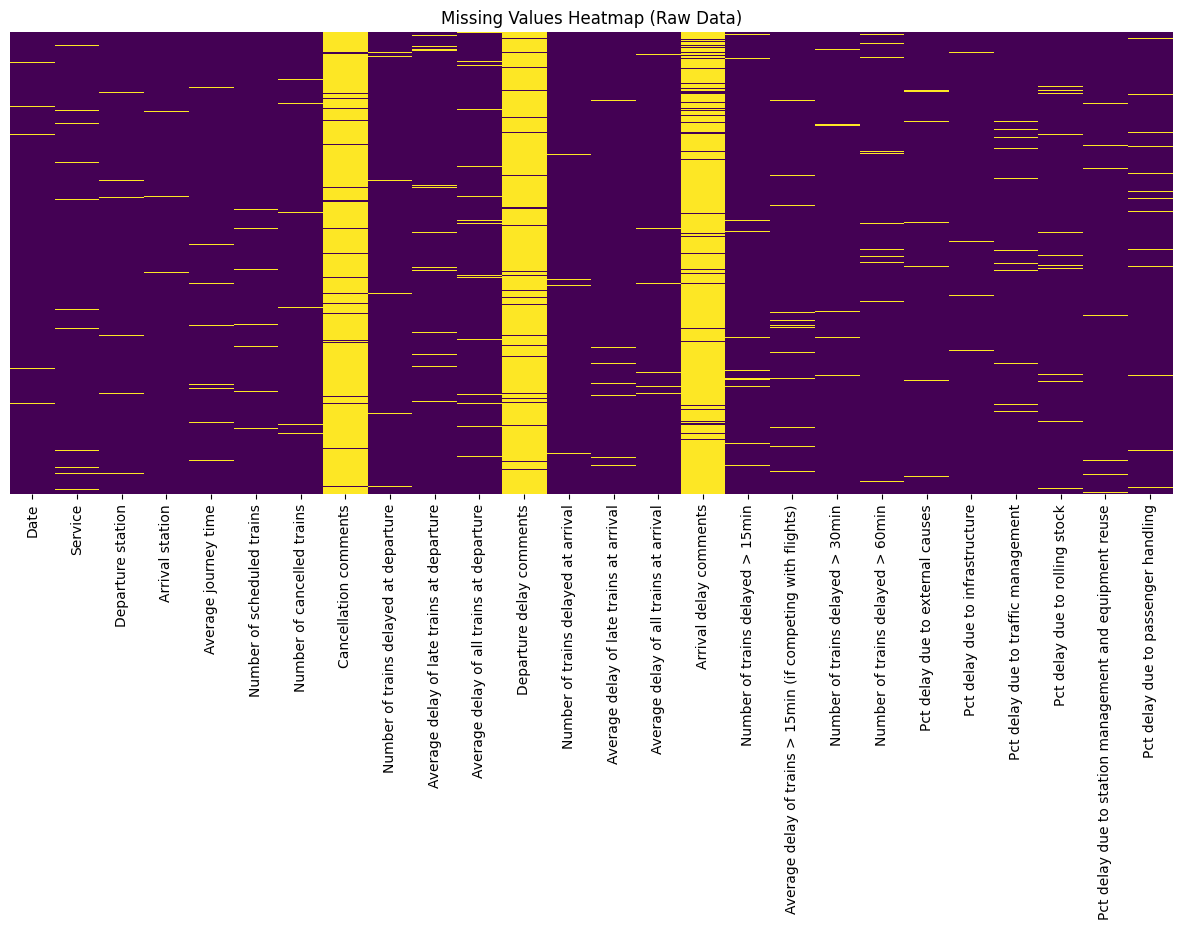

In [5]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Raw Data)')
plt.show()

## 2. Duplicate Removal
We remove identical rows to ensure data integrity.

In [6]:
df = df.drop_duplicates()

nb_line_after_dupes, _ = df.shape
print(f"Rows after duplicate removal: {nb_line_after_dupes} ({nb_line_start - nb_line_after_dupes} rows removed).")

Rows after duplicate removal: 11896 (174 rows removed).


## 3. Data Cleaning and Column Formatting

### Date Column
We standardize the `Date` column and extract `Year` and `Month` features.

In [7]:
# 1. Convert to datetime and standardize format
df['Date'] = pd.to_datetime(df['Date'], yearfirst=True, format='mixed')

# 2. Smart Fix: if a date is missing but the previous and next lines have the same date,
# we assume the missing date is the same.
date_coll = df['Date']
for i in range(1, len(df) - 1):
    if pd.isnull(date_coll.iloc[i]):
        if date_coll.iloc[i-1] == date_coll.iloc[i+1]:
            df.loc[df.index[i], 'Date'] = date_coll.iloc[i-1]

# 3. Drop remaining rows with missing dates (critical for analysis)
df = drop_invalid_rows(df, 'Date')

# 4. Extract Year and Month, then drop the original Date column
df['Year'] = df['Date'].dt.year.astype(int)
df['Month'] = df['Date'].dt.month.astype(int)
df = df.drop(columns=['Date'])

# 5. Place the Year and Month columns at the beginning of the DataFrame
cols = df.columns.tolist()
cols.remove('Year')
cols.remove('Month')
df = df[['Year', 'Month'] + cols]

print(f"Remaining rows after date validation: {len(df)}")
display(df[['Year', 'Month']].head())

Remaining rows after date validation: 11895


,Year,Month
0,2018,1
1,2018,1
2,2018,1
3,2018,1
4,2018,1


### Season Feature
We create a `Season` column based on the month.

In [8]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

#Place the Season column after Month
cols = df.columns.tolist()
cols.remove('Year')
cols.remove('Month')
cols.remove('Season')
df = df[['Year', 'Month', 'Season'] + cols]

display(df[['Month', 'Season']].head())

,Month,Season
0,1,Winter
1,1,Winter
2,1,Winter
3,1,Winter
4,1,Winter


### Service Column
We ensure the `Service` column only contains 'National' or 'International' values. Other values are set to `NaN`.

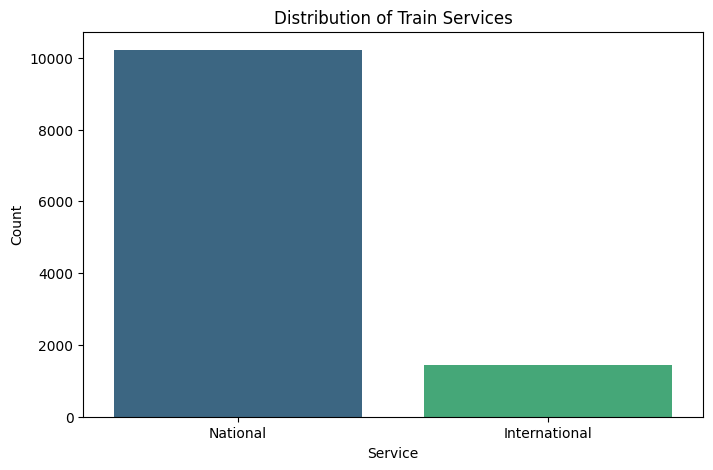

Rows with missing or invalid Service values: 240
Service counts:
Service
National         10216
International     1439
Name: count, dtype: int64


In [9]:
# List of valid service categories for the SNCF network
valid_services = ['national', 'international']

# 1. Convert to lowercase and strip whitespace for uniform comparison
df['Service'] = df['Service'].str.lower().str.strip()

# 2. Apply a transformation to each cell using a 'lambda' function:
# - If the value is valid, capitalize it ('national' -> 'National')
# - If the value is invalid/unknown, set it to 'pd.NA' (Missing Value)
df['Service'] = df['Service'].apply(lambda x: x.capitalize() if x in valid_services else pd.NA)

def find_service(row, catalog):
    # If the service is already provided, keep it
    if not pd.isna(row['Service']):
        return row['Service']
    
    # Otherwise, look for a "donor line" in our catalog with the same journey
    donor = catalog[
        (catalog['Departure station'] == row['Departure station']) &
        (catalog['Arrival station'] == row['Arrival station'])
    ]
    
    # If a donor is found, take its service
    if not donor.empty:
        return donor['Service'].iloc[0]
    
    # If nothing is found, keep it as NaN
    return pd.NA

# Visualize the distribution of service types to understand dataset balance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Service', hue='Service', palette='viridis', legend=False)
plt.title('Distribution of Train Services')
plt.ylabel('Count')
plt.show()

print(f"Rows with missing or invalid Service values: {df['Service'].isna().sum()}")
print("Service counts:")
print(df['Service'].value_counts())

### Departure and Arrival Stations
We convert station names to uppercase and remove rows with missing station information.

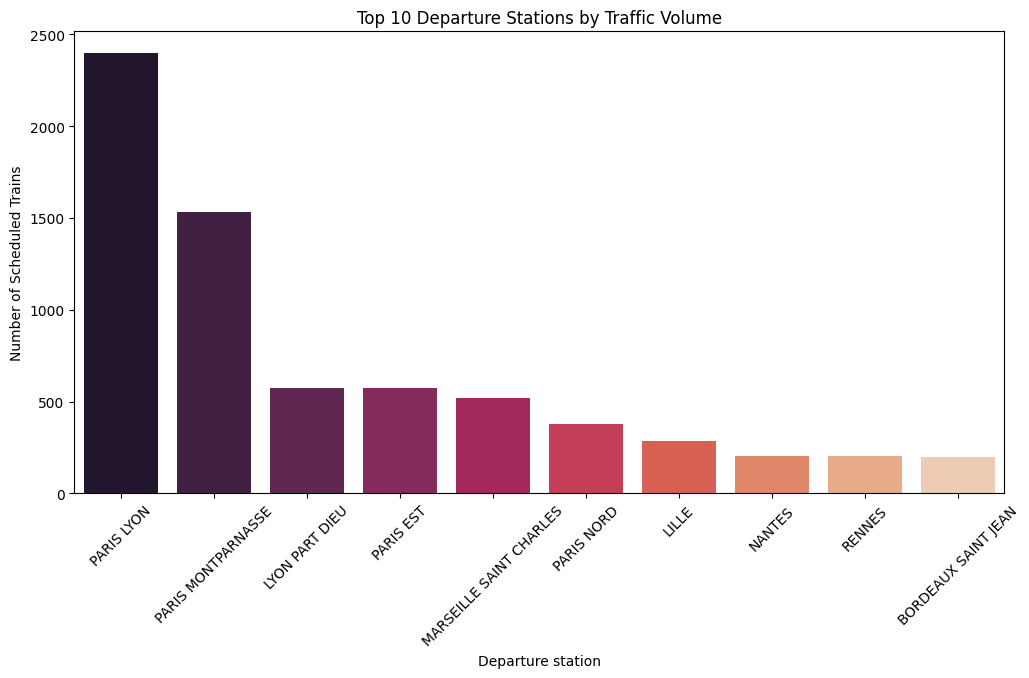

Service               2
Departure station    59
Arrival station      59
Season                4
dtype: int64

Final count after station validation: 11761


In [10]:
for col in ['Departure station', 'Arrival station']:
    # Standardize to uppercase and strip spaces
    df[col] = df[col].str.upper().str.strip()

    #Replace ST mention to SAINT
    df[col] = df[col].str.replace('ST ', 'SAINT ')

    # Replace null values with Pandas NA
    df[col] = df[col].replace(["NAN", "NULL", "0"], pd.NA)

    # Remove rows where station name is missing
    df = drop_invalid_rows(df, col)

# Create a "catalog" of known journeys
known_journeys = df.dropna(subset=['Service']).drop_duplicates(subset=['Departure station', 'Arrival station'])

# Attempt to fill missing Service values using the catalog of known journeys
df['Service'] = df.apply(lambda row: find_service(row, known_journeys), axis=1)

# Visualize Top 10 most frequent Departure Stations
plt.figure(figsize=(12, 6))
top_stations = df['Departure station'].value_counts().nlargest(10)
sns.barplot(x=top_stations.index, y=top_stations.values, hue=top_stations.index, palette='rocket', legend=False)
plt.title('Top 10 Departure Stations by Traffic Volume')
plt.xticks(rotation=45)
plt.ylabel('Number of Scheduled Trains')
plt.show()

print(df[['Service', 'Departure station', 'Arrival station', 'Season']].nunique())
print(f"\nFinal count after station validation: {len(df)}")

### Column Cleanup
We remove columns that contain no data or are not useful for our analysis to streamline the dataset.

In [11]:
# Drop unused comment columns and any other redundant data
cols_to_drop = ['Departure delay comments', 'Arrival delay comments', 'Cancellation comments']
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {len(df.columns)}")

Dropped columns: ['Departure delay comments', 'Arrival delay comments', 'Cancellation comments']
Remaining columns: 25


### Average Journey Time
We clean the journey time by removing the 'min' text and converting the values to integers. Missing values are kept as `NaN`.

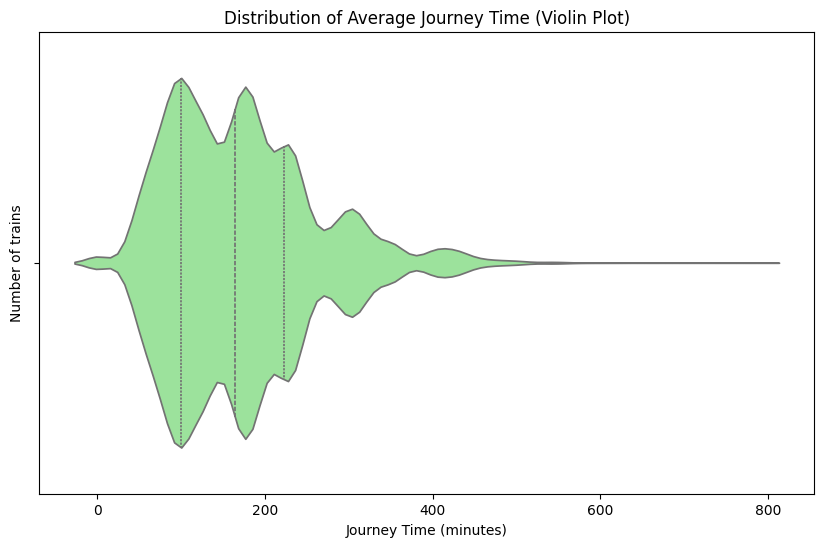

Missing values in Average journey time: 236


In [12]:
# Clean numeric data: remove 'min', handle commas, and convert to Integer
df = clean_numeric_column(df, 'Average journey time', text_to_remove='min', to_type='int')

# Null values for journey time are kept for further fix strategy.

# Visualize distribution using a Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['Average journey time'], color='lightgreen', inner='quartile')
plt.title('Distribution of Average Journey Time (Violin Plot)')
plt.xlabel('Journey Time (minutes)')
plt.ylabel('Number of trains')
plt.show()

print(f"Missing values in Average journey time: {df['Average journey time'].isna().sum()}")

### Scheduled and Cancelled Trains
We standardize the number of trains. We also implement a validation rule: the number of cancelled trains cannot exceed the number of scheduled trains.

In [13]:
# Clean Scheduled and Cancelled columns
df = clean_numeric_column(df, 'Number of scheduled trains', to_type='int')
df = clean_numeric_column(df, 'Number of cancelled trains', to_type='int')

# Validation: Cancelled trains cannot exceed Scheduled trains
incoherent_rows = df['Number of cancelled trains'] > df['Number of scheduled trains']
nb_invalid = incoherent_rows.sum()

if nb_invalid > 0:
    print(f"WARNING: {nb_invalid} rows found where cancellations exceed scheduled trains. Setting these cancellation counts to NULL.")
    df.loc[incoherent_rows, 'Number of cancelled trains'] = pd.NA

print(f"Missing 'Scheduled': {df['Number of scheduled trains'].isna().sum()}")
print(f"Missing 'Cancelled': {df['Number of cancelled trains'].isna().sum()}")

Missing 'Scheduled': 234
Missing 'Cancelled': 292


### Departure Delays
We clean the columns related to delays at the departure station. We apply logic validation:
1. Number of delayed trains cannot exceed scheduled trains.
2. If zero trains were delayed, the average delay of late trains must be zero.

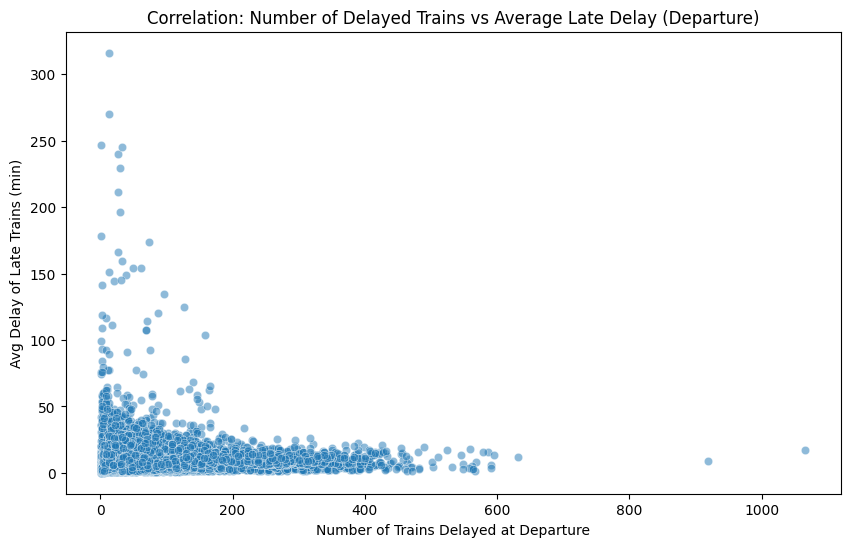

Missing values check:
Number of trains delayed at departure        251
Average delay of late trains at departure    364
Average delay of all trains at departure     234
dtype: int64


In [14]:
# Clean numeric
df = clean_numeric_column(df, 'Number of trains delayed at departure', to_type='int')
df = clean_numeric_column(df, 'Average delay of late trains at departure', text_to_remove='min', to_type='float')
df = clean_numeric_column(df, 'Average delay of all trains at departure', text_to_remove='min', to_type='float')

# Round floats to 2 decimal places for clarity
df['Average delay of late trains at departure'] = df['Average delay of late trains at departure'].round(2)
df['Average delay of all trains at departure'] = df['Average delay of all trains at departure'].round(2)

# Validation 1: Delayed trains > Scheduled trains
incoherent_rows = df['Number of trains delayed at departure'] > df['Number of scheduled trains']
if incoherent_rows.any():
    print(f"WARNING: {incoherent_rows.sum()} rows found where delayed trains exceed scheduled trains. Setting to NULL.")
    df.loc[incoherent_rows, 'Number of trains delayed at departure'] = pd.NA

# Validation 2: If no trains delayed, average late delay must be NaN
zero_delayed_rows = (df['Number of trains delayed at departure'] == 0)
df.loc[zero_delayed_rows, 'Average delay of late trains at departure'] = np.nan

# Visualize correlation between number of delayed trains and average delay
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of trains delayed at departure', y='Average delay of late trains at departure', alpha=0.5)
plt.title('Correlation: Number of Delayed Trains vs Average Late Delay (Departure)')
plt.xlabel('Number of Trains Delayed at Departure')
plt.ylabel('Avg Delay of Late Trains (min)')
plt.show()

print("Missing values check:")
print(df[['Number of trains delayed at departure', 'Average delay of late trains at departure', 'Average delay of all trains at departure']].isna().sum())

### Arrival Delays
We clean the columns related to delays at the arrival station. Similar to departure delays, we apply validation rules:
1. Number of delayed trains cannot exceed scheduled trains.
2. If zero trains were delayed, the average delay of late trains must be zero.

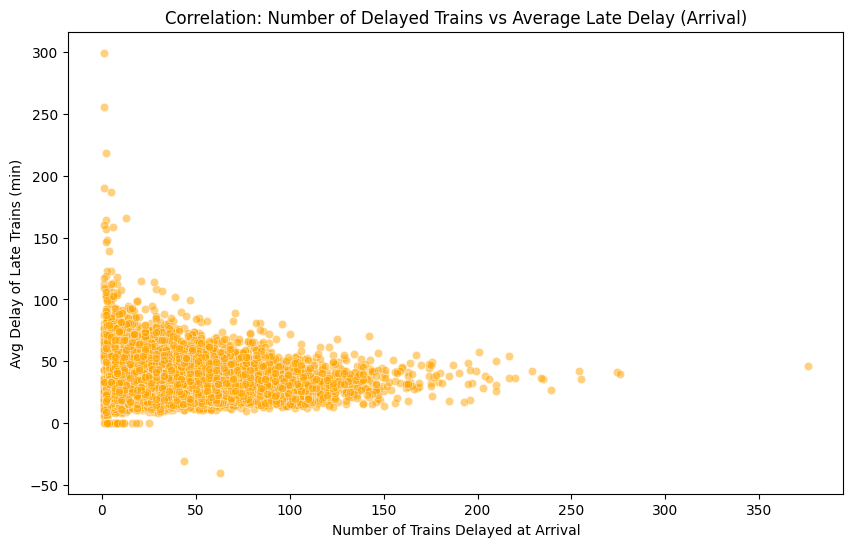

Missing values check (Arrival):
Number of trains delayed at arrival        234
Average delay of late trains at arrival    418
Average delay of all trains at arrival     233
dtype: int64


In [15]:
# Clean numeric
df = clean_numeric_column(df, 'Number of trains delayed at arrival', to_type='int')
df = clean_numeric_column(df, 'Average delay of late trains at arrival', text_to_remove='min', to_type='float')
df = clean_numeric_column(df, 'Average delay of all trains at arrival', text_to_remove='min', to_type='float')

# Round floats to 2 decimal places
df['Average delay of late trains at arrival'] = df['Average delay of late trains at arrival'].round(2)
df['Average delay of all trains at arrival'] = df['Average delay of all trains at arrival'].round(2)

# Validation 1: Delayed trains > Scheduled trains
incoherent_rows = df['Number of trains delayed at arrival'] > df['Number of scheduled trains']
if incoherent_rows.any():
    print(f"WARNING: {incoherent_rows.sum()} rows found where delayed arrival trains exceed scheduled. Setting to NULL.")
    df.loc[incoherent_rows, 'Number of trains delayed at arrival'] = pd.NA

# Validation 2: If no trains delayed at arrival, average late delay must be NaN
zero_delayed_rows = (df['Number of trains delayed at arrival'] == 0)
df.loc[zero_delayed_rows, 'Average delay of late trains at arrival'] = np.nan

# Visualize correlation between number of delayed trains and average delay at arrival
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of trains delayed at arrival', y='Average delay of late trains at arrival', alpha=0.5, color='orange')
plt.title('Correlation: Number of Delayed Trains vs Average Late Delay (Arrival)')
plt.xlabel('Number of Trains Delayed at Arrival')
plt.ylabel('Avg Delay of Late Trains (min)')
plt.show()

print("Missing values check (Arrival):")
print(df[['Number of trains delayed at arrival', 'Average delay of late trains at arrival', 'Average delay of all trains at arrival']].isna().sum())

### Delay and Severity
We clean the columns that categorize delays (>15min, >30min, >60min). 
We also include the average delay for routes competing with flights.

**Validation Rules:**
A logical 'cascade' must be maintained: Total Delayed Arrival >= Delayed > 15min >= Delayed > 30min >= Delayed > 60min.

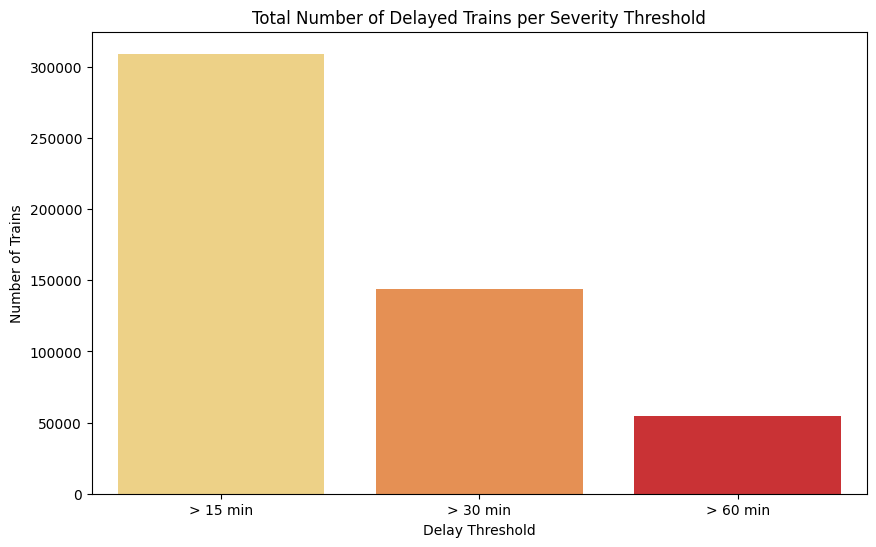

Missing values summary for delay thresholds:
Number of trains delayed > 15min                               265
Number of trains delayed > 30min                               237
Number of trains delayed > 60min                               580
Average delay of trains > 15min (if competing with flights)    234
dtype: int64


In [16]:
# Clean categorized delay counts as Integers
df = clean_numeric_column(df, 'Number of trains delayed > 15min', to_type='int')
df = clean_numeric_column(df, 'Number of trains delayed > 30min', to_type='int')
df = clean_numeric_column(df, 'Number of trains delayed > 60min', to_type='int')

# Clean flight competition average as Float
df = clean_numeric_column(df, 'Average delay of trains > 15min (if competing with flights)', text_to_remove='min', to_type='float')
df['Average delay of trains > 15min (if competing with flights)'] = df['Average delay of trains > 15min (if competing with flights)'].round(2)

# Validation: Cascade Logic (>15 >= >30 >= >60)
incoherent_rows_15_30 = df['Number of trains delayed > 15min'] < df['Number of trains delayed > 30min']
incoherent_rows_30_60 = df['Number of trains delayed > 30min'] < df['Number of trains delayed > 60min']
incoherent_rows_total_15 = df['Number of trains delayed at arrival'] < df['Number of trains delayed > 15min']

if incoherent_rows_15_30.any() or incoherent_rows_30_60.any() or incoherent_rows_total_15.any():
    total_errors = (incoherent_rows_15_30 | incoherent_rows_30_60 | incoherent_rows_total_15).sum()
    print(f"WARNING: {total_errors} rows found with inconsistent delay cascades. Setting invalid counts to NULL.")
    # Set inconsistent values to NULL
    df.loc[incoherent_rows_15_30, 'Number of trains delayed > 30min'] = pd.NA
    df.loc[incoherent_rows_30_60, 'Number of trains delayed > 60min'] = pd.NA
    df.loc[incoherent_rows_total_15, 'Number of trains delayed > 15min'] = pd.NA

# Visualize delay severity levels
delay_sums = df[['Number of trains delayed > 15min', 'Number of trains delayed > 30min', 'Number of trains delayed > 60min']].sum()
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_sums.index, y=delay_sums.values, hue=delay_sums.index, palette='YlOrRd', legend=False)
plt.title('Total Number of Delayed Trains per Severity Threshold')
plt.xlabel('Delay Threshold')
plt.ylabel('Number of Trains')
plt.xticks(ticks=[0, 1, 2], labels=['> 15 min', '> 30 min', '> 60 min'])
plt.show()

print("Missing values summary for delay thresholds:")
print(df[['Number of trains delayed > 15min', 'Number of trains delayed > 30min', 'Number of trains delayed > 60min', 'Average delay of trains > 15min (if competing with flights)']].isna().sum())

### Percentage Delay by Cause
We clean the columns representing the percentage of delays attributed to different causes (External, Infrastructure, etc.).

**Smart Strategy:**
1. If multiple values are missing in a row, we leave them as `NaN` (unrecoverable).
2. If only one value is missing, we calculate it such that the total sum equals 100%.
3. If the sum of existing values is already 100%, any missing value is set to 0.0.

In [17]:
# List of columns representing percentages of delay causes
percentage_cols = [
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling'
]
# Clean numeric format for all percentage columns
for col in percentage_cols:
    df = clean_numeric_column(df, col, text_to_remove='%', to_type='float')
    df[col] = df[col].round(2)
# Smart Recalculation: Identify rows with exactly one missing percentage value
null_counts = df[percentage_cols].isnull().sum(axis=1)
recalculable_rows = (null_counts == 1)
if recalculable_rows.any():
    print(f"Recalculating missing percentage for {recalculable_rows.sum()} rows where 5/6 causes are present.")
    # Calculate the sum of the non-missing values
    current_sums = df.loc[recalculable_rows, percentage_cols].sum(axis=1)
    # For each row, find the single null column and fill it with (100 - sum)
    for idx in df[recalculable_rows].index:
        row = df.loc[idx, percentage_cols]
        missing_col = row[row.isnull()].index[0]
        # Ensure the value is not negative (possible if data is corrupted > 100%)
        calculated_val = max(0.0, 100.0 - current_sums[idx])
        df.loc[idx, missing_col] = round(calculated_val, 2)
# For rows where all values are already 100%, set any remaining NaNs to 0.0
df[percentage_cols] = df[percentage_cols].fillna(0.0)
# Final Consistency Check: Verify the total sum per row
df['Pct delay sum'] = df[percentage_cols].sum(axis=1)
incoherent_percentages = ~df['Pct delay sum'].between(99.0, 101.0)
if incoherent_percentages.any():
    print(f"WARNING: {incoherent_percentages.sum()} rows still have inconsistent percentage sums. Setting them to NULL.")
    df.loc[incoherent_percentages, percentage_cols] = pd.NA
# Drop temporary sum column
df = df.drop(columns=['Pct delay sum'])
print("Percentage columns cleaned and validated.")

Recalculating missing percentage for 1304 rows where 5/6 causes are present.
Percentage columns cleaned and validated.


### Exporting the cleaned dataset

In [18]:
df.to_csv("cleaned_dataset.csv", sep=";", index=False)

## Dataset after cleaning

In [19]:
print("Column names and new types are: ")

#We get names of columns in the Dataframe
columns = df.columns
for i in range(len(columns)):
    print(columns[i], end=" -> ")
    print(df[str(columns[i])].dtype)

nb_line, nb_col = df.shape

print(f"\nThere is {nb_col} columns and {nb_line} line in the new dataset.\n- {nb_line_start - nb_line} lines has been removed\n- {nb_col_start - nb_col} columns has been removed.\n {((nb_line_start - nb_line) / nb_line_start * 100):.2f}% of the dataset lines were removed")

display(df)

Column names and new types are: 
Year -> int64
Month -> int64
Season -> str
Service -> str
Departure station -> str
Arrival station -> str
Average journey time -> Int64
Number of scheduled trains -> Int64
Number of cancelled trains -> Int64
Number of trains delayed at departure -> Int64
Average delay of late trains at departure -> float64
Average delay of all trains at departure -> float64
Number of trains delayed at arrival -> Int64
Average delay of late trains at arrival -> float64
Average delay of all trains at arrival -> float64
Number of trains delayed > 15min -> Int64
Average delay of trains > 15min (if competing with flights) -> float64
Number of trains delayed > 30min -> Int64
Number of trains delayed > 60min -> Int64
Pct delay due to external causes -> float64
Pct delay due to infrastructure -> float64
Pct delay due to traffic management -> float64
Pct delay due to rolling stock -> float64
Pct delay due to station management and equipment reuse -> float64
Pct delay due to pass

,Year,Month,Season,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,Pct delay due to passenger handling
0,2018,1,Winter,National,BORDEAUX SAINT JEAN,PARIS MONTPARNASSE,141,870,5,289,...,110,6.51,44,8,36.13,31.09,10.92,15.97,5.04,0.84
1,2018,1,Winter,National,LE MANS,PARIS MONTPARNASSE,56,406,1,213,...,32,5.36,9,4,20.00,35.00,16.67,16.67,8.33,3.33
2,2018,1,Winter,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,21,...,11,2.94,6,1,22.22,27.78,16.67,16.67,5.56,11.11
3,2018,1,Winter,National,PARIS MONTPARNASSE,NANTES,216,508,3,71,...,39,5.29,18,<NA>,33.33,22.22,16.67,20.37,5.56,1.85
4,2018,1,Winter,National,POITIERS,PARIS MONTPARNASSE,94,472,4,224,...,42,4.88,10,0,15.79,45.61,19.31,15.79,1.75,1.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12033,2018,11,Autumn,National,SAINT ETIENNE CHATEAUCREUX,PARIS LYON,168,113,1,19,...,14,5.51,5,2,21.05,36.84,5.26,21.05,10.53,5.26
12034,2021,5,Spring,National,PARIS MONTPARNASSE,NANTES,138,470,29,48,...,6,31.45,3,0,22.22,0.00,11.11,33.33,0.00,33.33
12049,2018,3,Spring,National,PERPIGNAN,PARIS LYON,305,163,1,63,...,23,8.47,14,7,57.14,14.29,14.29,14.29,0.00,0.00
12056,2019,2,Winter,National,NICE VILLE,PARIS LYON,357,159,4,32,...,33,9.32,13,5,18.18,36.36,24.24,12.12,9.09,0.00


### Cleaning efficiency visualisation
After the cleaning process we identify which cells were fixed, which were removed from the original dataset

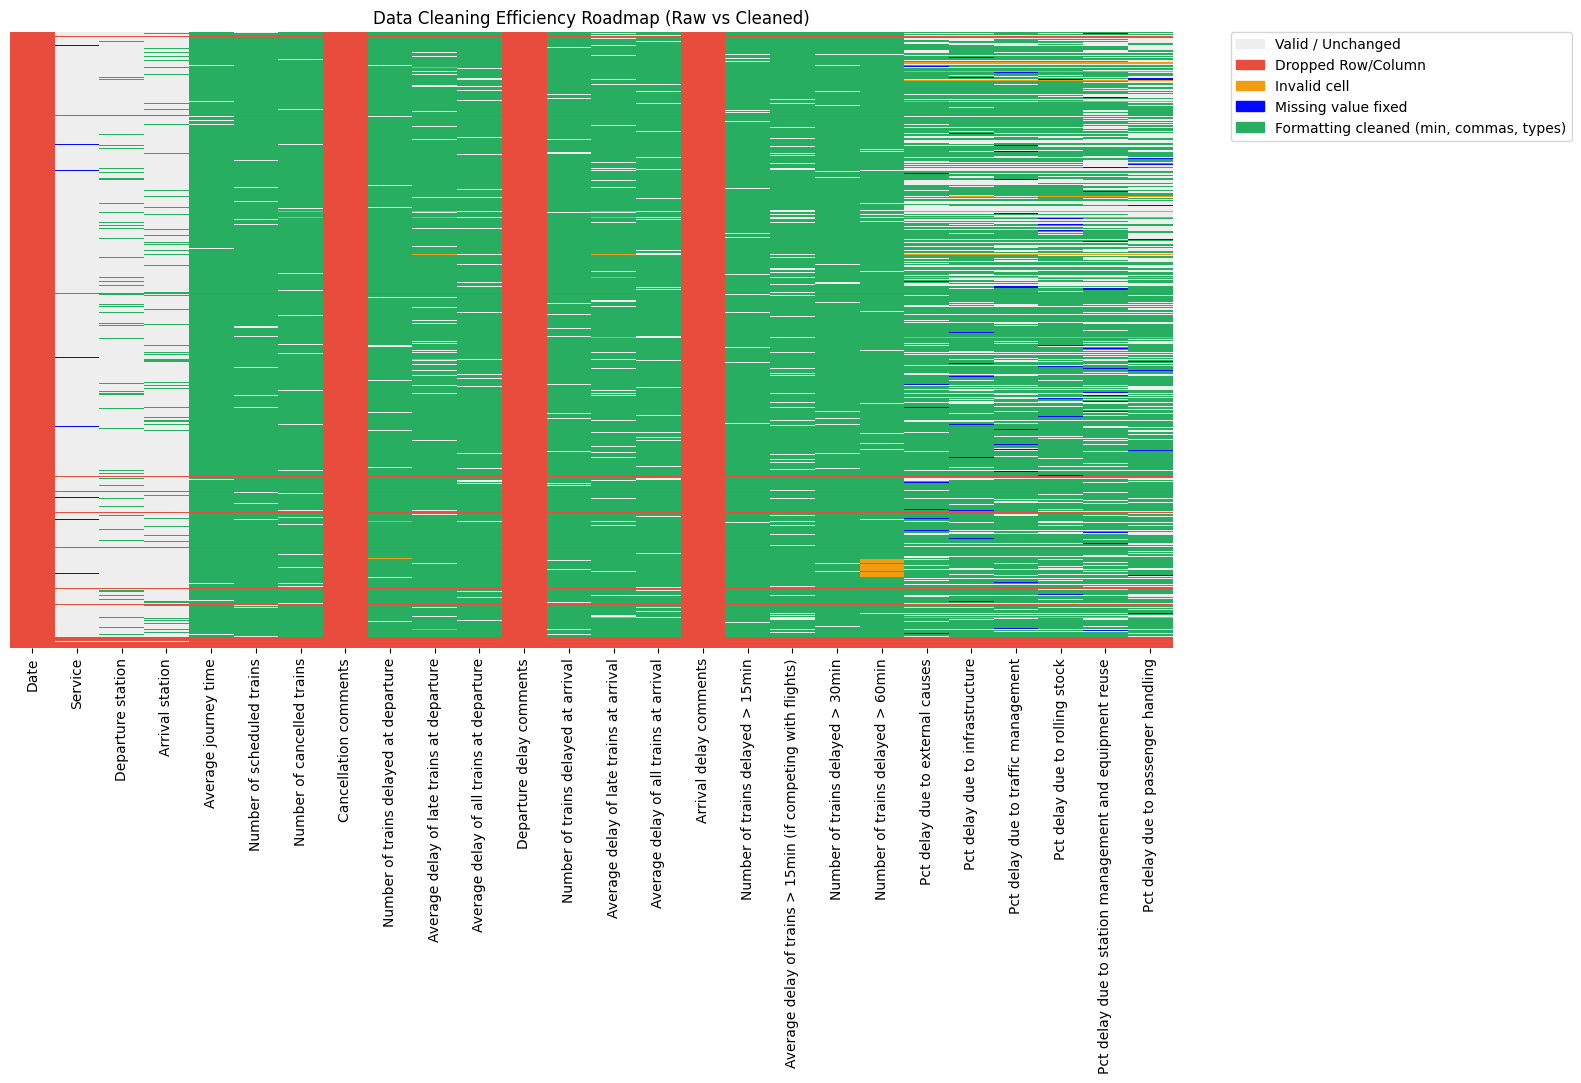

In [20]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 1. Prepare a status matrix based on df_raw
status_matrix = pd.DataFrame(0, index=df_raw.index, columns=df_raw.columns)

# 2. Identify Dropped Rows (Red - Code 1)
dropped_rows = df_raw.index.difference(df.index)
status_matrix.loc[dropped_rows, :] = 1

# Align cleaned data to raw data structure for comparison
df_aligned = df.reindex_like(df_raw)

for col in df_raw.columns:
    if col not in df.columns:
        status_matrix[col] = 1 # Column was dropped
        continue
        
    raw_col = df_raw[col]
    clean_col = df_aligned[col]
    
    # 3. Errors set to NULL (Orange - Code 2)
    # Was not null in raw, but is null in cleaned (excluding dropped rows (Red))
    nullified = raw_col.notnull() & clean_col.isnull()
    status_matrix.loc[nullified & ~status_matrix.index.isin(dropped_rows), col] = 2
    
    # 4. Missing values fixed (Blue - Code 3)
    # Was null in raw, now has a value
    fixed = raw_col.isnull() & clean_col.notnull()
    status_matrix.loc[fixed, col] = 3
    
    # 5. Values cleaned/formatted (Green - Code 4)
    # Difference in values that are NOT null in both
    # We use string comparison to detect formatting changes (commas, 'min', etc.)
    cleaned = (raw_col.astype(str).str.strip() != clean_col.astype(str).str.strip()) & \
              raw_col.notnull() & clean_col.notnull()
    status_matrix.loc[cleaned & ~status_matrix.index.isin(dropped_rows), col] = 4

# --- Visualisation ---
plt.figure(figsize=(15, 8))

# Palette: Gray (0: Unchanged), Red (1: Dropped), Orange (2: Inconsistency), Blue (3: Fixed), Green (4: Cleaned)
colors = ['#EEEEEE', '#e74c3c', '#f39c12', '#0008ff', '#27ae60']
custom_cmap = ListedColormap(colors)

# Create a heatmap to visualize the cleaning status of each cell
sns.heatmap(status_matrix, cbar=False, yticklabels=False, cmap=custom_cmap)
plt.title('Data Cleaning Efficiency Roadmap (Raw vs Cleaned)')

# Custom Legend
legend_labels = {
    'Valid / Unchanged': '#EEEEEE',
    'Dropped Row/Column': '#e74c3c',
    'Invalid cell': '#f39c12',
    'Missing value fixed': '#0008ff',
    'Formatting cleaned (min, commas, types)': '#27ae60'
}
# Create custom legend patches
patches = [mpatches.Patch(color=color, label=label) for label, color in legend_labels.items()]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

# Bilan of the first step

Lorem ipsum

# Step 2 - Data Visualisation and Analysis

Now that we have cleaned the dataset, we can use them to understand the dataset better. It will be useful to improve the predictive model accuracy.

In [21]:
#We get the dataset cleaned from the file
new = pd.read_csv("cleaned_dataset.csv", sep=";")

## Statistics

## Graphics

### Relation between cancelled trains in function of departure station

We observe the percentage of cancelled trains in function of departure station

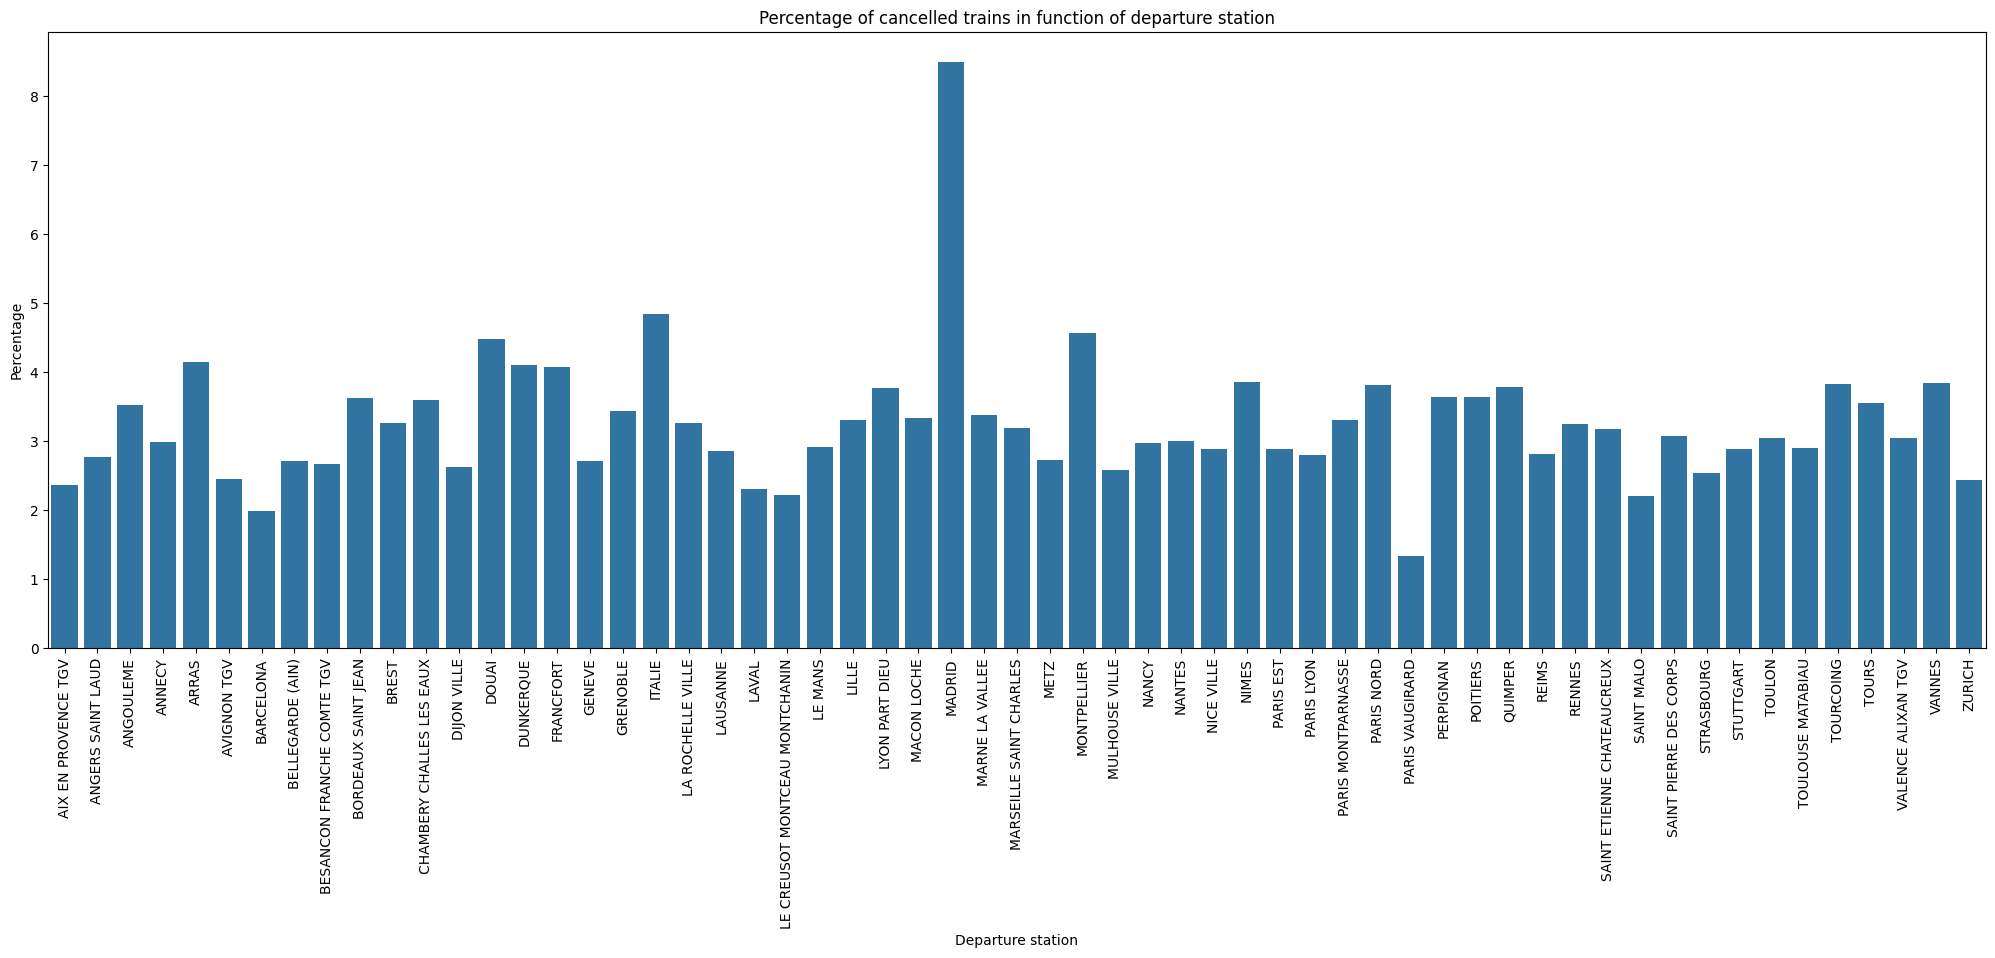

In [22]:
#Decide size of graphic
plt.figure(figsize=(25,8))

#Exclude all columns with 0 in name of departure
temp = new[new["Departure station"] != "0"]

#Group rows by departure stations and choose to sum datas of numeric columns
temp = temp.groupby("Departure station").aggregate("sum")

#New column with correlation between cancelled trains and scheduled ones
temp['Correlation cancelled / schedule'] = 100 * temp['Number of cancelled trains'] / temp['Number of scheduled trains']

#Taking datas from dataset and precise columns that are put in relation
sns.barplot(data=temp, x='Departure station', y='Correlation cancelled / schedule')
plt.title('Percentage of cancelled trains in function of departure station')
plt.xticks(rotation=90)
plt.ylabel('Percentage')
plt.show()

Here, we can observe that the city with the most proportion of cancelled train over total scheduled train is Madrid with 8 trains cancelled for 100 scheduled. And the station with less cancelled train for number of schedule trains is Paris Vaugirard with 1 for 100. But for other cities, it's pretty the same everywhere.

### Relation between late at departure in function of the season

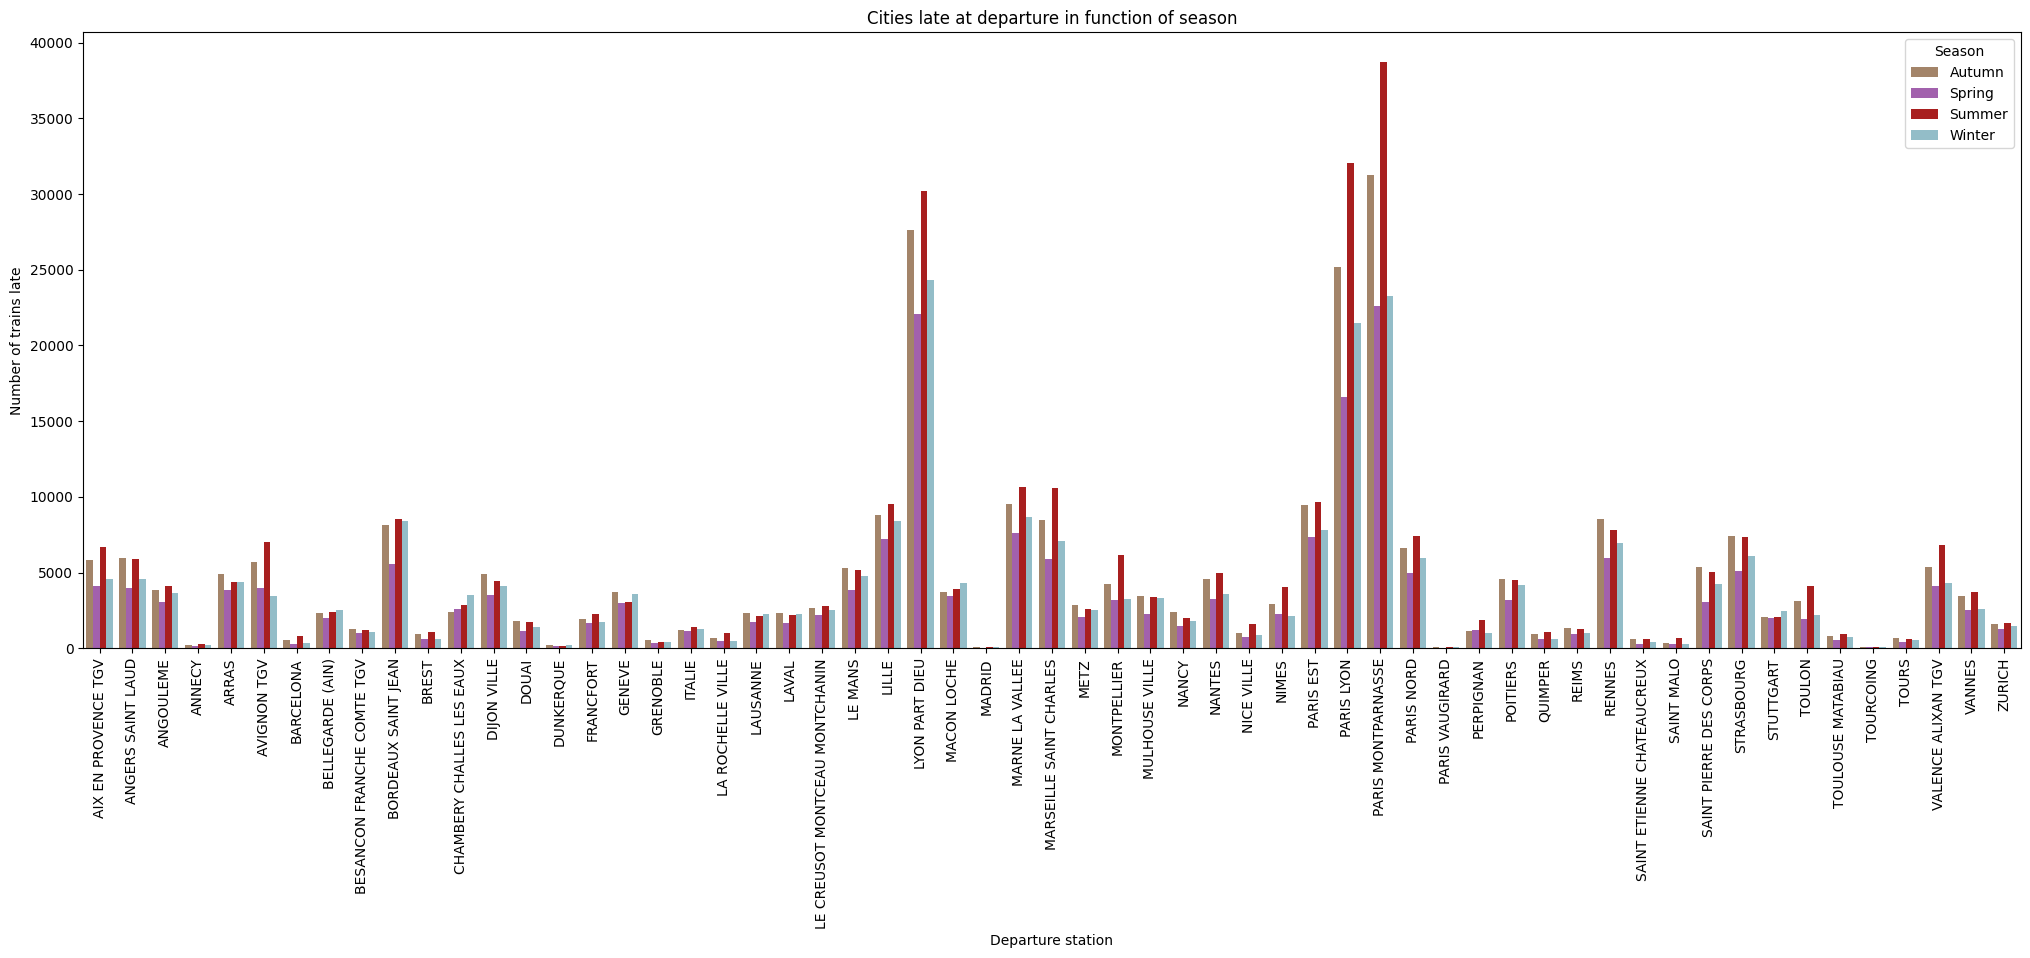

In [23]:
#Decide which season has which color
palette = {"Winter": "#8AC2D1", "Summer": "#BF0808", "Autumn": "#AD835F", "Spring": "#AB54BA"}

#Decide size of graphic
plt.figure(figsize=(25,8))

#Exlude 0 as names and get original dataset
seasons = new[new["Departure station"] != "0"]

#Get seasons and departure stations and choose to sum datas of numeric columns
seasons = seasons.groupby(["Departure station", "Season"]).aggregate("sum").reset_index()

#Taking datas from dataset and precise columns that are put in relation
sns.barplot(data=seasons, x='Departure station', y='Number of trains delayed at departure', hue='Season', palette=palette)
plt.title('Cities late at departure in function of season')
plt.xticks(rotation=90)
plt.ylabel('Number of trains late')
plt.show()

**Conclusion**
- We can observe that :
    - There's a lot of late at departure at Lyon Part Dieu, Paris Lyon and Paris Montparnasse stations.
    - The average number of trains delayed at departure is between 5000 and 10000.
    - The season with the most late at departure is Summer and the less is Spring

### Relation between late at departure in function of the season

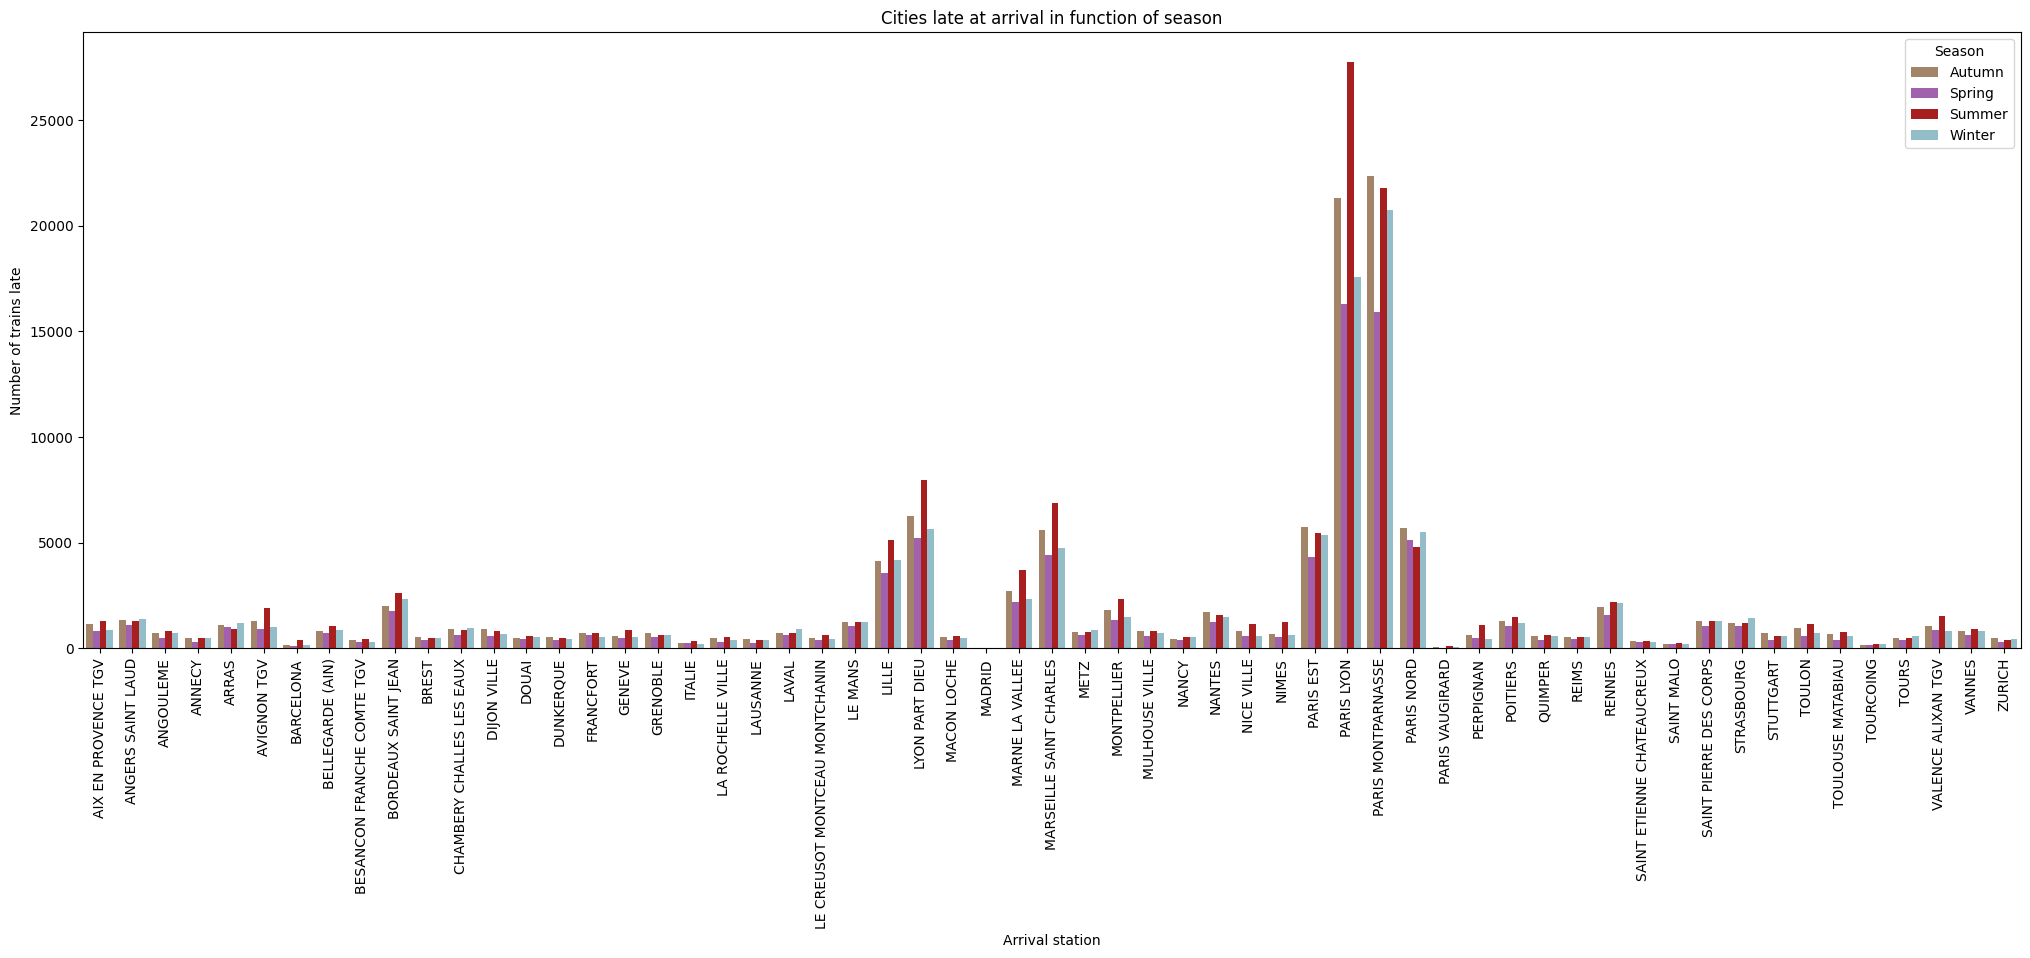

In [24]:
#Decide size of graphic
plt.figure(figsize=(25,8))

#Exlude 0 as names and get original dataset
seasons = new[new["Arrival station"] != "0"]

#Get seasons and arrival stations and choose to sum datas of numeric columns
seasons = seasons.groupby(["Arrival station", "Season"]).aggregate("sum").reset_index()

#Taking datas from dataset and precise columns that are put in relation
sns.barplot(data=seasons, x='Arrival station', y='Number of trains delayed at arrival', hue='Season', palette=palette)
plt.title('Cities late at arrival in function of season')
plt.xticks(rotation=90)
plt.ylabel('Number of trains late')
plt.show()

**Conclusion**
- We can observe that :
    - There's a lot of late at arrival at Paris Lyon and Paris Montparnasse stations.
    - The average number of trains delayed at arrival is below 5000.
    - The season with the most late at arrival is Summer and the less is Spring.